In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import arrow
import netCDF4 as nc
from salishsea_tools import visualisations as vis
from salishsea_tools import viz_tools
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean.cm as cm
import pandas as pd
import datetime as dt

from IPython.display import Video


In [2]:
meshmask = xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
tmask = meshmask.tmask
mbathy = meshmask.mbathy
bathy = nc.Dataset('/ocean/atall/MOAD/grid/bathymetry_202108.nc')
mesh = nc.Dataset('/ocean/atall/MOAD/grid/mesh_mask202108.nc')
depth = mesh.variables['gdept_0'][:]
thalweg_SI = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/SaanichInlet_thalweg.txt' 
thalweg_PB = '/ocean/atall/MOAD/analysis-abdoul/notebooks/thalweg_work/thalweg_files/PatriciaBay_CrossSection.txt' 
thalweg_SoG = '/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt'
thalweg_ptsSI = np.loadtxt(thalweg_SI, delimiter=' ', dtype=int)
thalweg_ptsPB = np.loadtxt(thalweg_PB, delimiter=' ', dtype=int)
thalweg_ptsSoG = np.loadtxt(thalweg_SoG, delimiter=' ', dtype=int)

### Along the thalwegs: Salish sea, Saanich Inlet

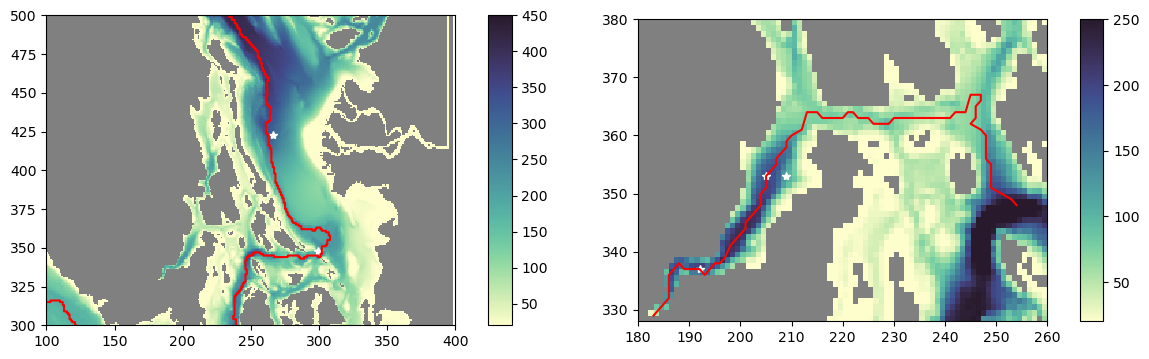

In [19]:
line, col = (1, 2)
fig, ax = plt.subplots(line, col, figsize=(14, 6))
mycmap = cm.deep
mycmap.set_bad('grey')
for ii in range(0, col):
    if ii==0:
        thalweg=thalweg_ptsSoG
        ax[ii].set_xlim([100, 400])
        ax[ii].set_ylim([300, 500])
        vmin,vmax=(20,450)
        ax[ii].plot(266, 423,'w*') # Central Node
        ax[ii].plot(299, 348,'w*')
    else:
        thalweg=thalweg_ptsSI
        ax[ii].set_xlim([180, 260])
        ax[ii].set_ylim([328, 380])
        vmin,vmax=(20,250)
        ax[ii].plot(209, 353,'w*') # Patricia bay
        ax[ii].plot(205, 353,'w*')
        ax[ii].plot(192, 337,'w*')
        #ax[ii].plot(196, 338,'w*')

    im = ax[ii].pcolormesh(bathy.variables['Bathymetry'][:], cmap=mycmap, vmin=vmin, vmax=vmax)
    ax[ii].plot(thalweg[:,1],thalweg[:,0],color='r')
    viz_tools.set_aspect(ax[ii]);
    divider = make_axes_locatable(ax[ii])
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

### animation

In [3]:
# Compute timeseries along the thalwegs
syear, smonth, sday = (2018, 1, 1)
eyear, emonth, eday = (2018, 12, 31)
startdate = arrow.get(syear, smonth, sday)
enddate = arrow.get(eyear, emonth, eday)
dir21 = '/results2/SalishSea/nowcast-green.202111/'
dirWW = '/data/sallen/results/MEOPAR/wastewater/long_run/'
#dir = '/ocean/atall/MOAD/Model/202410b/oxygen/'
thalweg = list([thalweg_ptsSI[::-1],thalweg_ptsSoG,thalweg_ptsPB])
j=1 #change region
cmap = cm.balance
first = True
for iii, day in enumerate(arrow.Arrow.range('day', startdate, enddate)):
    year = day.year
    yr2 = day.strftime("%y")
    month = day.month
    Month = day.strftime("%b").lower()
    day = day.day
    # set up filename to follow NEMO conventions
    ds_chem21 = xr.open_dataset(f'{dir21}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc') 
    ds_chemWW = xr.open_dataset(f'{dirWW}{day:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{day:02}_{year}{month:02}{day:02}_chem_T.nc') 
    vars = ds_chemWW.dissolved_oxygen-ds_chem21.dissolved_oxygen
    dep_thal, distance, oxy_thal = vis.load_thalweg(depth[0, ...], np.array(vars).mean(axis=0), bathy['nav_lon'][:], bathy['nav_lat'][:],thalweg[j])
    if first:
        first = False
        oxyTS = oxy_thal
    else:
        oxyTS = np.vstack((oxyTS, oxy_thal))  
oxy = oxyTS.reshape(len(oxyTS)//len(vars['deptht']),len(vars['deptht']),len(thalweg[j]))      

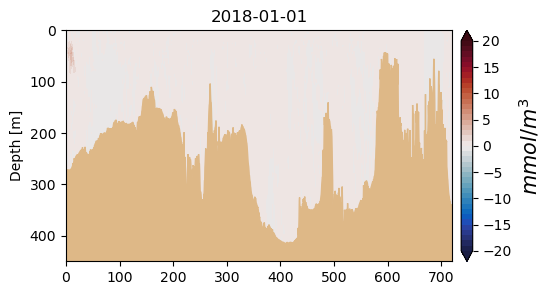

In [4]:
# Plot and save animations
depmin = list([300,450,200])
region = list(['Saanich','SoG','PatBay'])
title = 'DO'
var = oxy
spacef = np.linspace(-20, 20, 41)
spacec = [10, 85]
fig, axs = plt.subplots(1, 1, figsize=(6, 3))
var_plot = vis._fill_in_bathy(var[0,...], mesh, thalweg[j])
colourf_var = axs.contourf(distance, dep_thal, var_plot, spacef, cmap=cmap, extend='both')
#colourc_var = axs.contour(distance, dep_thal, var_plot, spacec, colors='k', extend='both')
vis._add_bathy_patch(distance, bathy['Bathymetry'][:], thalweg[j], axs, color='burlywood')
axs.invert_yaxis()
axs.set_ylabel('Depth [m]');
axs.set_ylim([depmin[j], 0])
cbar = fig.colorbar(colourf_var, ax=axs, pad=0.02)
cbar.ax.set_ylabel(r'$mmol/m^3$',fontsize=15)
#fig.suptitle(f'{title}: 202410', fontsize=12)
dtime = pd.to_datetime(np.arange(dt.datetime(syear,smonth,sday), dt.datetime(eyear,emonth,eday), dt.timedelta(days=1)).astype(dt.time)).strftime("%Y-%m-%d")
def newframe(fnum):
    var_plot = vis._fill_in_bathy(var[fnum,...], mesh, thalweg[j])
    colourf_var = axs.contourf(distance, dep_thal, var_plot, spacef, cmap=cmap, extend='both')
    axs.contour(distance, dep_thal, var_plot, [100, 350], cmap=cmap, zorder=1)
    colourf_var.set_array(var_plot.ravel())
    vis._add_bathy_patch(distance, bathy['Bathymetry'][:], thalweg[j], axs, color='burlywood')
    axs.set_title(str(dtime.values[fnum]))

ani = FuncAnimation(fig, newframe, frames=len(dtime), interval=200, repeat=False)
ani.save('figs/Animation_WWIona-202111_{}.mp4'.format(f'{region[j]}_{title}'), fps=5)
#plt.close(fig)  


In [3]:
# Time settings
syear, smonth, sday = (2018, 1, 1)
eyear, emonth, eday = (2018, 1, 30)
startdate = arrow.get(syear, smonth, sday)
enddate = arrow.get(eyear, emonth, eday)

# Directories
dir21 = '/results2/SalishSea/nowcast-green.202111/'
dirWW = '/data/sallen/results/MEOPAR/wastewater/long_run/'

# Containers
do_list, nitrate_list, ammonium_list = [], [], []

# Loop over days
for day in arrow.Arrow.range('day', startdate, enddate):
    year = day.year
    yr2 = day.strftime("%y")
    month = day.month
    Month = day.strftime("%b").lower()
    dayn = day.day

    # Filenames
    fn_chem21 = f'{dir21}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_chemWW = f'{dirWW}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_chem_T.nc'
    fn_biol21 = f'{dir21}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'
    fn_biolWW = f'{dirWW}{dayn:02}{Month}{yr2}/SalishSea_1d_{year}{month:02}{dayn:02}_{year}{month:02}{dayn:02}_biol_T.nc'

    # Open datasets
    ds_chem21 = xr.open_dataset(fn_chem21)
    ds_chemWW = xr.open_dataset(fn_chemWW)
    ds_biol21 = xr.open_dataset(fn_biol21)
    ds_biolWW = xr.open_dataset(fn_biolWW)

    # Depth mask for top 10 m
    mask_10m_chem = ds_chem21.deptht < 10
    mask_10m_biol = ds_biol21.deptht < 10

    # DO difference over first 10 m
    do_diff = ds_chemWW.dissolved_oxygen - ds_chem21.dissolved_oxygen
    do_10m = do_diff.isel(deptht=mask_10m_chem).mean(dim='deptht')
    do_list.append(do_10m)

    # Nitrate difference over first 10 m
    nitrate_diff = ds_biolWW.nitrate - ds_biol21.nitrate
    nitrate_10m = nitrate_diff.isel(deptht=mask_10m_biol).mean(dim='deptht')
    nitrate_list.append(nitrate_10m)

    # Ammonium difference over first 10 m
    ammonium_diff = ds_biolWW.ammonium - ds_biol21.ammonium
    ammonium_10m = ammonium_diff.isel(deptht=mask_10m_biol).mean(dim='deptht')
    ammonium_list.append(ammonium_10m)

# Convert to xarray.DataArray along time
time_index = pd.date_range(start=f"{syear}-{smonth:02}-{sday:02}", end=f"{eyear}-{emonth:02}-{eday:02}", freq="D")

do_da = xr.concat(do_list, dim='time')
nitrate_da = xr.concat(nitrate_list, dim='time')
ammonium_da = xr.concat(ammonium_list, dim='time')

do_da['time'] = time_index[:len(do_list)]
nitrate_da['time'] = time_index[:len(nitrate_list)]
ammonium_da['time'] = time_index[:len(ammonium_list)]

In [69]:
do_surf = do_da.mean(axis=1)
nitrate_surf = nitrate_da.mean(axis=1)
ammonium_surf = ammonium_da.mean(axis=1)

# Choose levels
levels_do = np.linspace(-20, 20, 21)
levels_nitrate = np.linspace(-5, 5, 21)
levels_ammonium = np.linspace(-0.1, 0.1, 21)
cmap = 'RdBu_r'

lon = meshmask.nav_lon
lat = meshmask.nav_lat

# Prepare figure
fig, axs = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# Initial plots
cf1 = axs[0].contourf(lon, lat, do_surf.isel(time=0), levels=levels_do, cmap=cmap, extend='both')
cf2 = axs[1].contourf(lon, lat, nitrate_surf.isel(time=0), levels=levels_nitrate, cmap=cmap, extend='both')
cf3 = axs[2].contourf(lon, lat, ammonium_surf.isel(time=0), levels=levels_ammonium, cmap=cmap, extend='both')

axs[0].set_title(f'DO difference on {str(do_surf.time.values[0])[:10]} (0-10m)')
axs[1].set_title(f'Nitrate difference on {str(nitrate_surf.time.values[0])[:10]} (0-10m)')
axs[2].set_title(f'Ammonium difference on {str(ammonium_surf.time.values[0])[:10]} (0-10m)')

# Colorbars
fig.colorbar(cf1, ax=axs[0], label='DO diff (mmol/m³)')
fig.colorbar(cf2, ax=axs[1], label='Nitrate diff (mmol/m³)')
fig.colorbar(cf3, ax=axs[2], label='Ammonium diff (mmol/m³)')

# Update function
def update(frame):
    for ax in axs:
        for coll in ax.collections:
            coll.remove()
    axs[0].contour(lon, lat, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
    axs[1].contour(lon, lat, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
    axs[2].contour(lon, lat, mbathy[0,:,:], linewidths=1, levels=[-0.01, 0.01], colors='dimgray')
    cf1 = axs[0].contourf(lon, lat, do_surf.isel(time=frame), levels=levels_do, cmap=cmap, extend='both')
    cf2 = axs[1].contourf(lon, lat, nitrate_surf.isel(time=frame), levels=levels_nitrate, cmap=cmap, extend='both')
    cf3 = axs[2].contourf(lon, lat, ammonium_surf.isel(time=frame), levels=levels_ammonium, cmap=cmap, extend='both')
    axs[0].set_title(f'DO difference on {str(do_surf.time.values[frame])[:10]} (0-10m)')
    axs[1].set_title(f'Nitrate difference on {str(nitrate_surf.time.values[frame])[:10]} (0-10m)')
    axs[2].set_title(f'Ammonium difference on {str(ammonium_surf.time.values[frame])[:10]} (0-10m)')
    return cf1.collections + cf2.collections + cf3.collections

# Create animation
ani = FuncAnimation(fig, update, frames=len(do_surf.time), blit=False)

# Save
ani.save('figs/chem_animation_Jan.mp4', writer='ffmpeg', fps=2)

plt.close(fig)  # close static plot

# Display video
Video("figs/chem_animation_Jan.mp4", embed=True)